# Nhiệm vụ 3: Xây dựng rừng cây (Random Forest)

## Bước 1. Tải thư viện và nạp dữ liệu

In [54]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400  # Độ phân giải cao cho hình ảnh
import graphviz
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Nạp dữ liệu
df = pd.read_csv('default_of_credit_card_clients.csv')
features_response = df.columns.tolist()

# Loại bỏ các cột không liên quan
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'EDUCATION_CAT', 'graduate school', 'high school', 'none', 'others', 'university']
features_response = [item for item in features_response if item not in items_to_remove]

## Bước 2. Chuẩn bị dữ liệu cho tập train và tập test

In [55]:
# Chia dữ liệu thành tập train và tập test
X_train, X_test, y_train, y_test = train_test_split(df[features_response[:-1]].values, df['default payment next month'].values, test_size=0.2, random_state=24)

## Bước 3. Tạo và huấn luyện mô hình Random Forest

In [56]:
# Khởi tạo mô hình Random Forest
rf = RandomForestClassifier(n_estimators=10, criterion='gini', max_depth=3, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=4, verbose=0, warm_start=False, class_weight=None)

# Huấn luyện mô hình
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=10, random_state=4)

## Bước 4. Tìm tham số tối ưu cho mô hình Random Forest

In [57]:
# Định nghĩa lưới tham số
rf_params_ex = {'n_estimators': list(range(10, 110, 10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex, scoring='roc_auc', n_jobs=None, refit=True, cv=4, verbose=1, error_score=0, return_train_score=True)

# Huấn luyện với GridSearchCV
cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4, error_score=0,
             estimator=RandomForestClassifier(max_depth=3, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

## Bước 5. Vẽ biểu đồ đánh giá mô hình

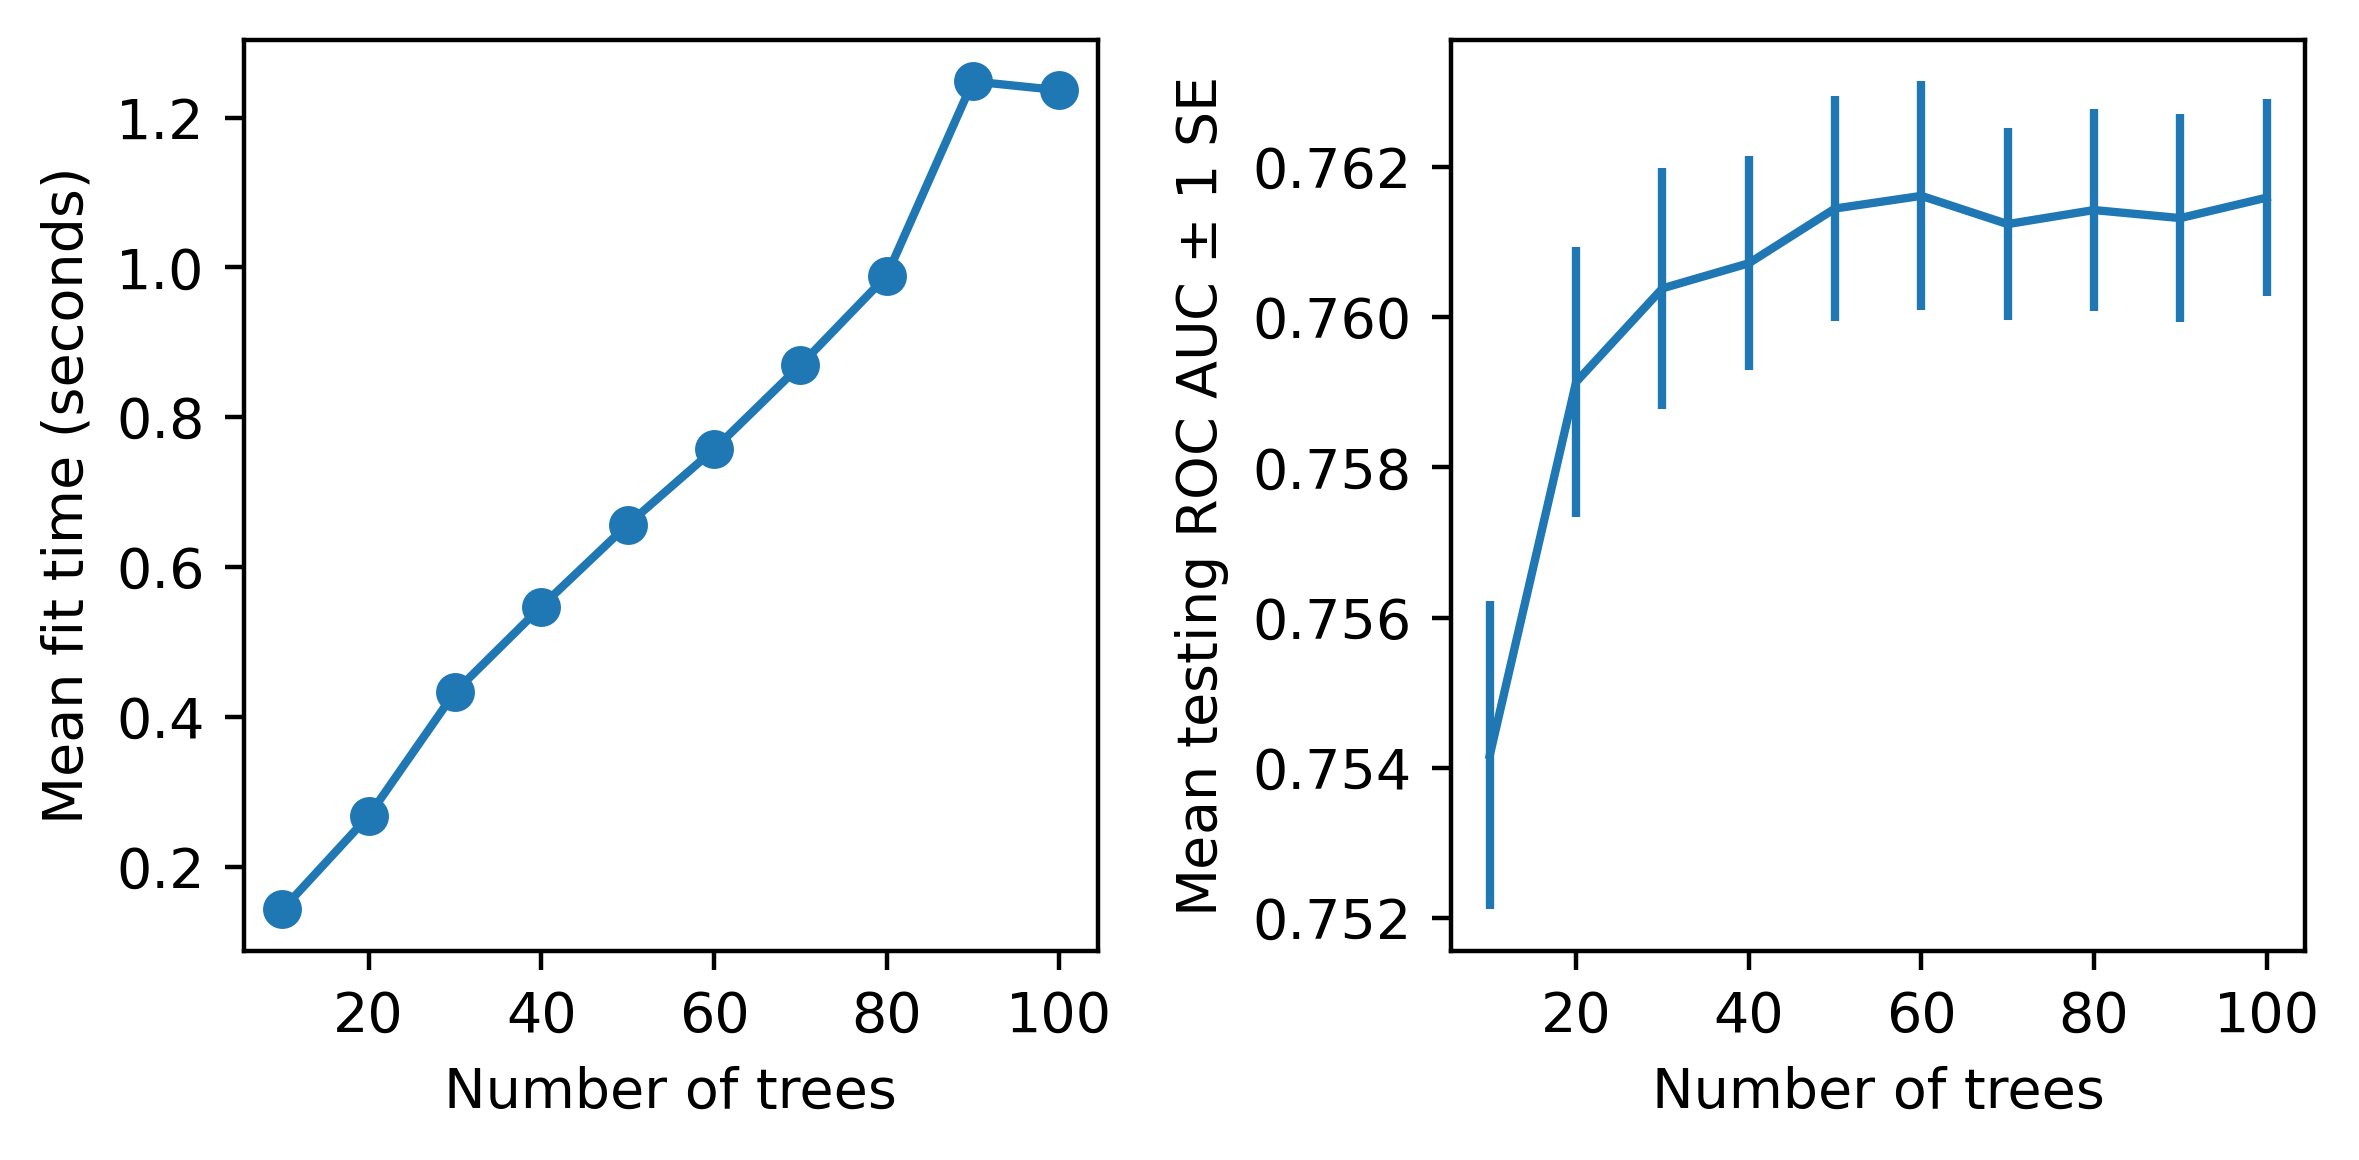

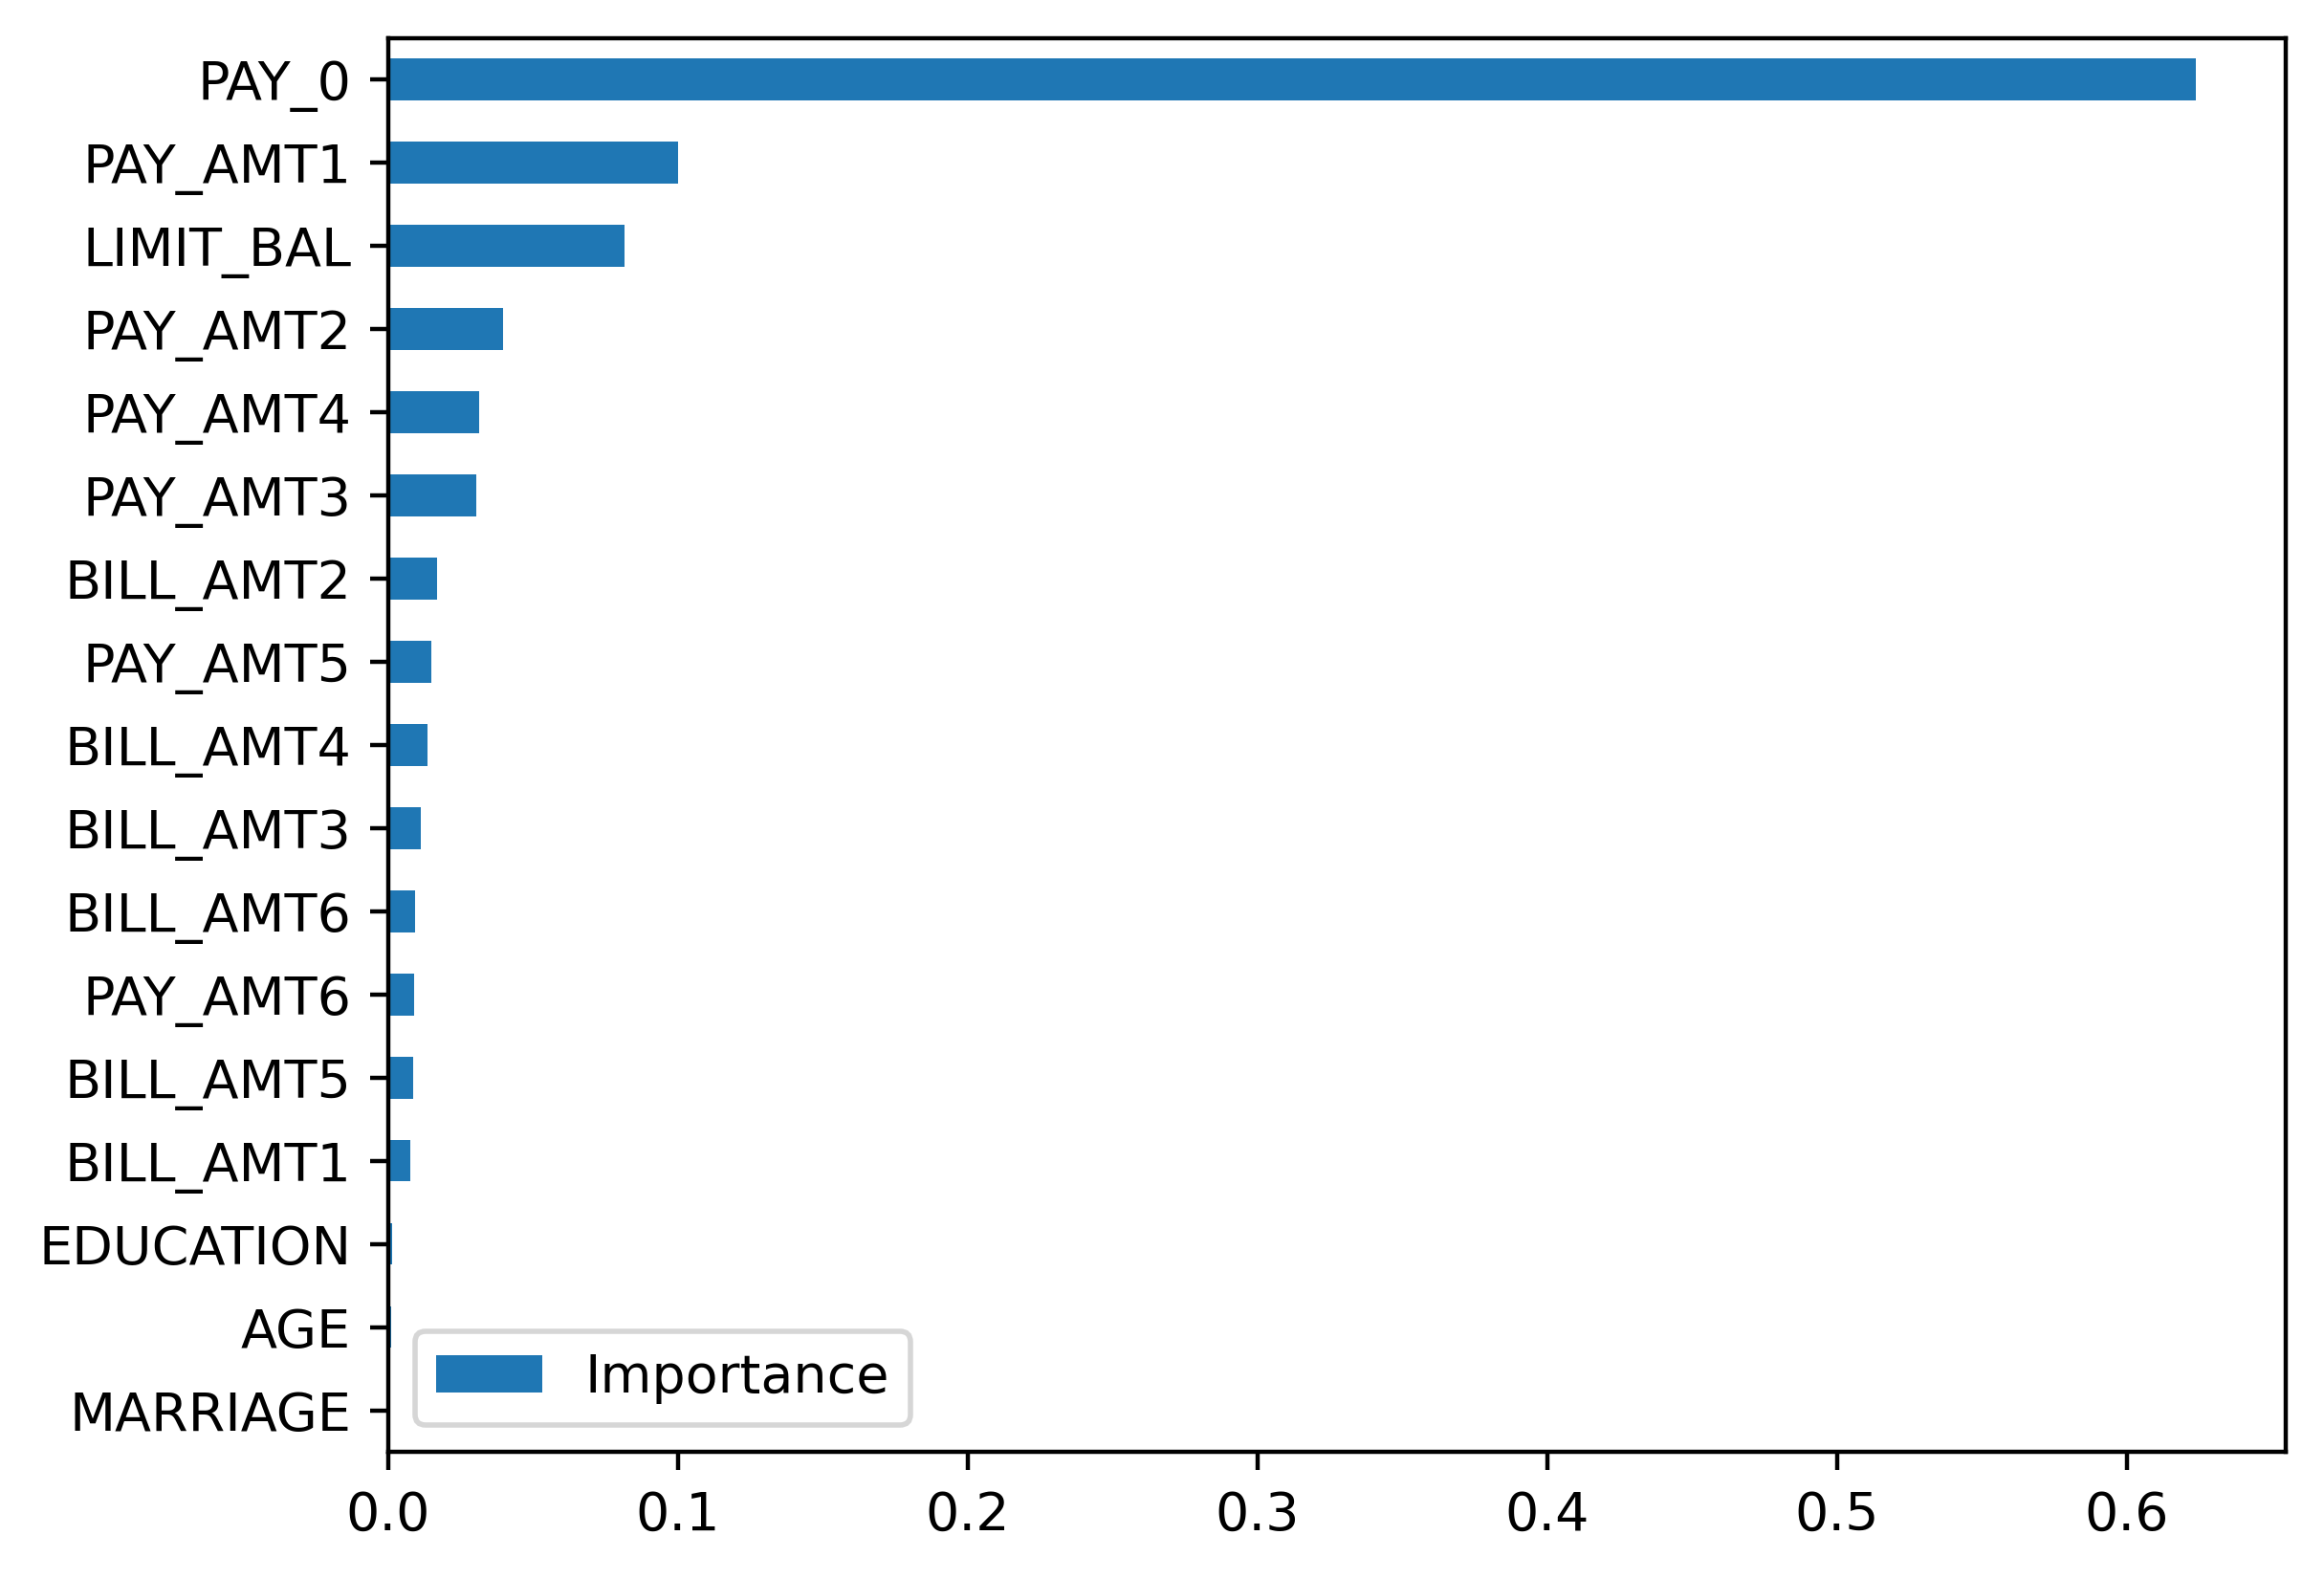

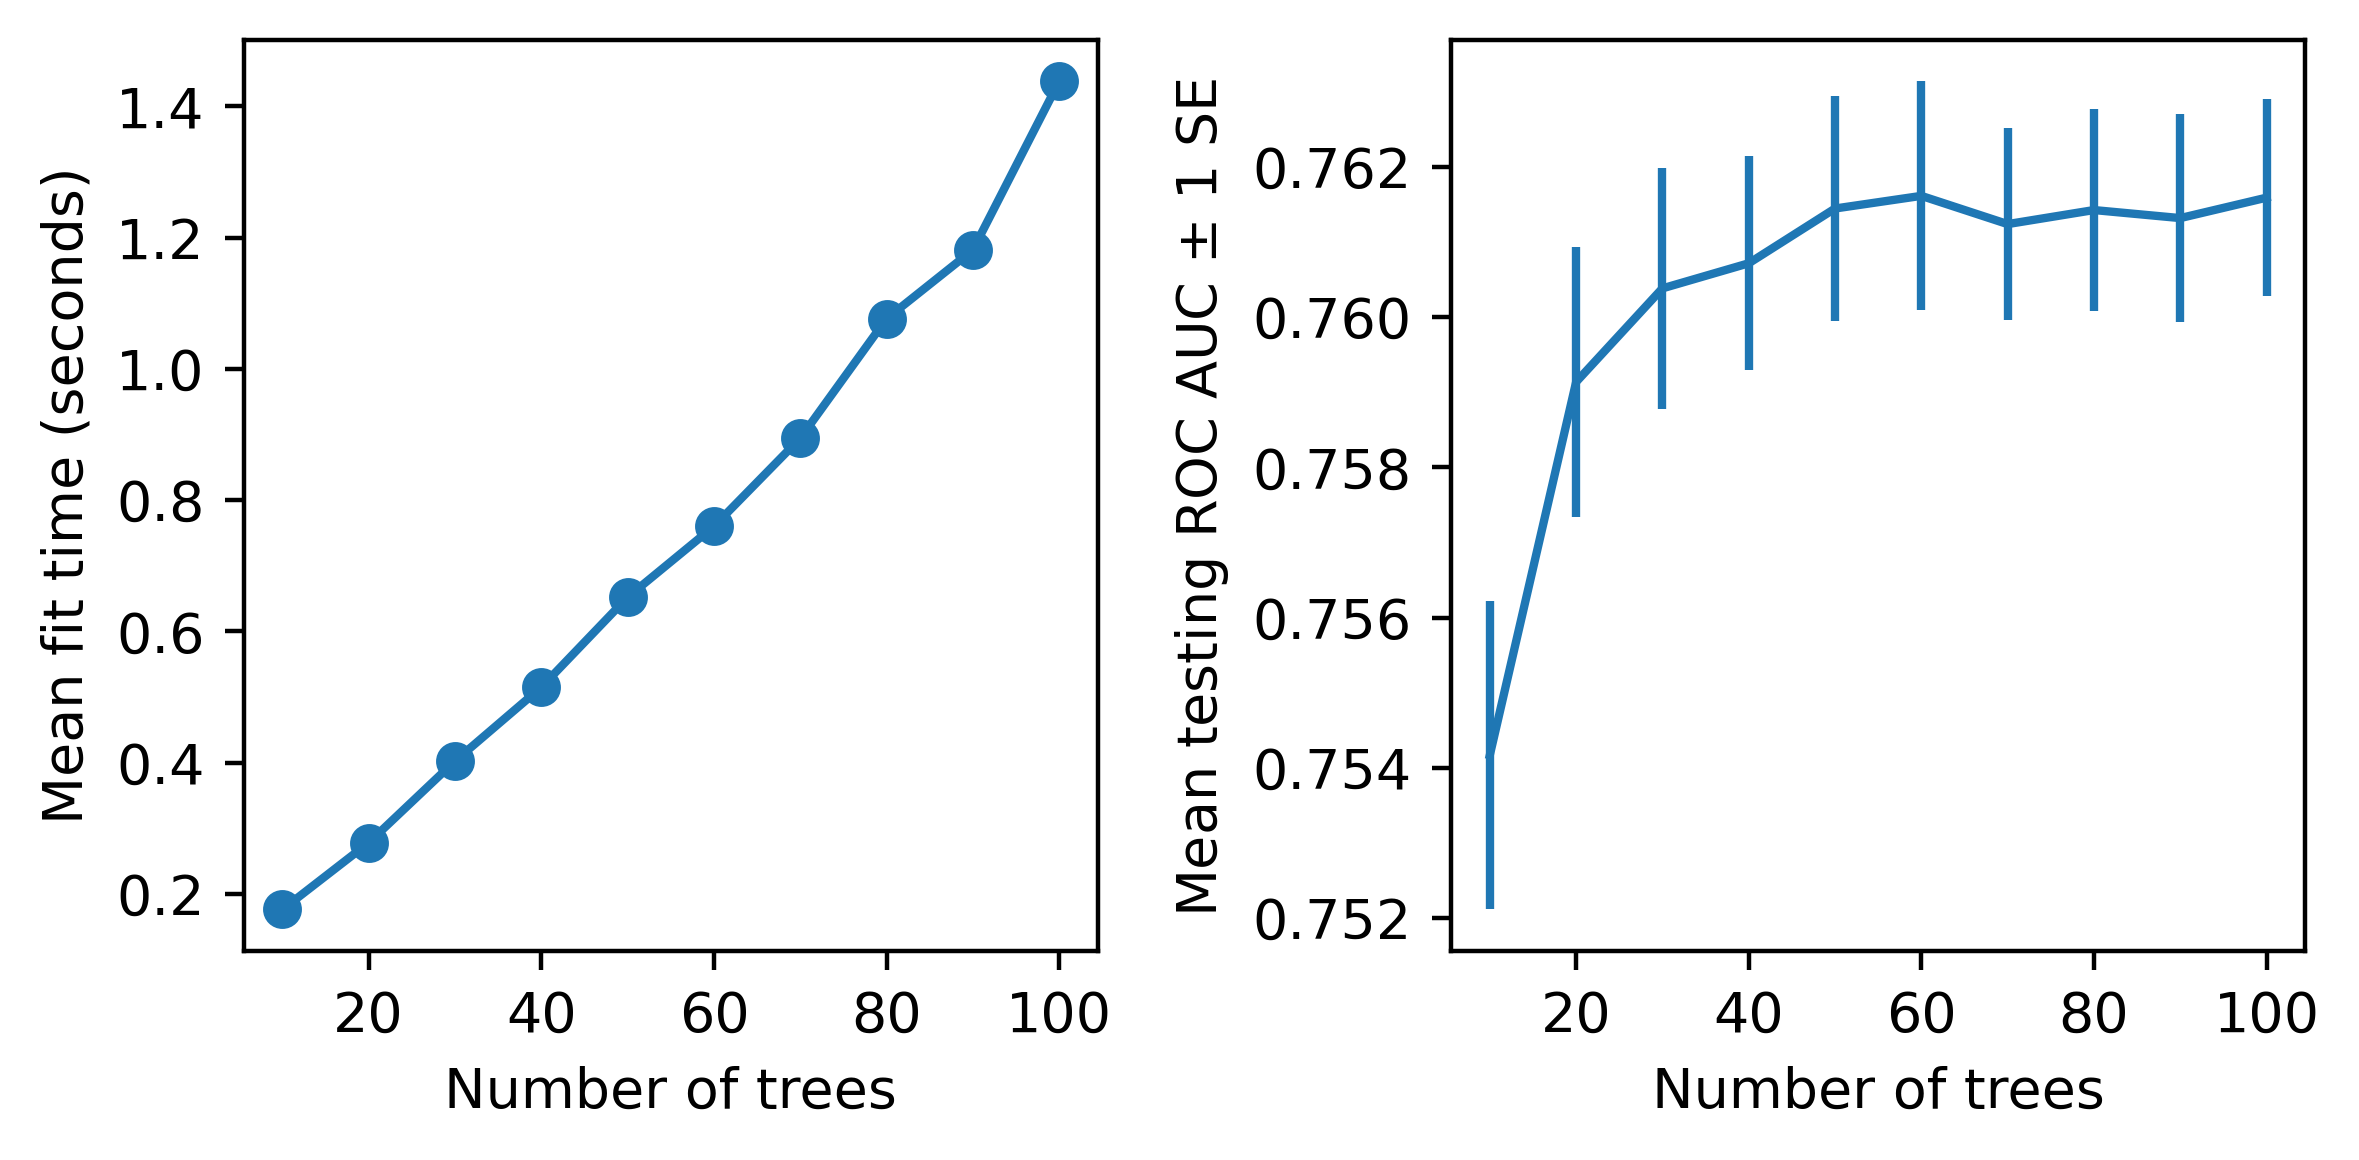

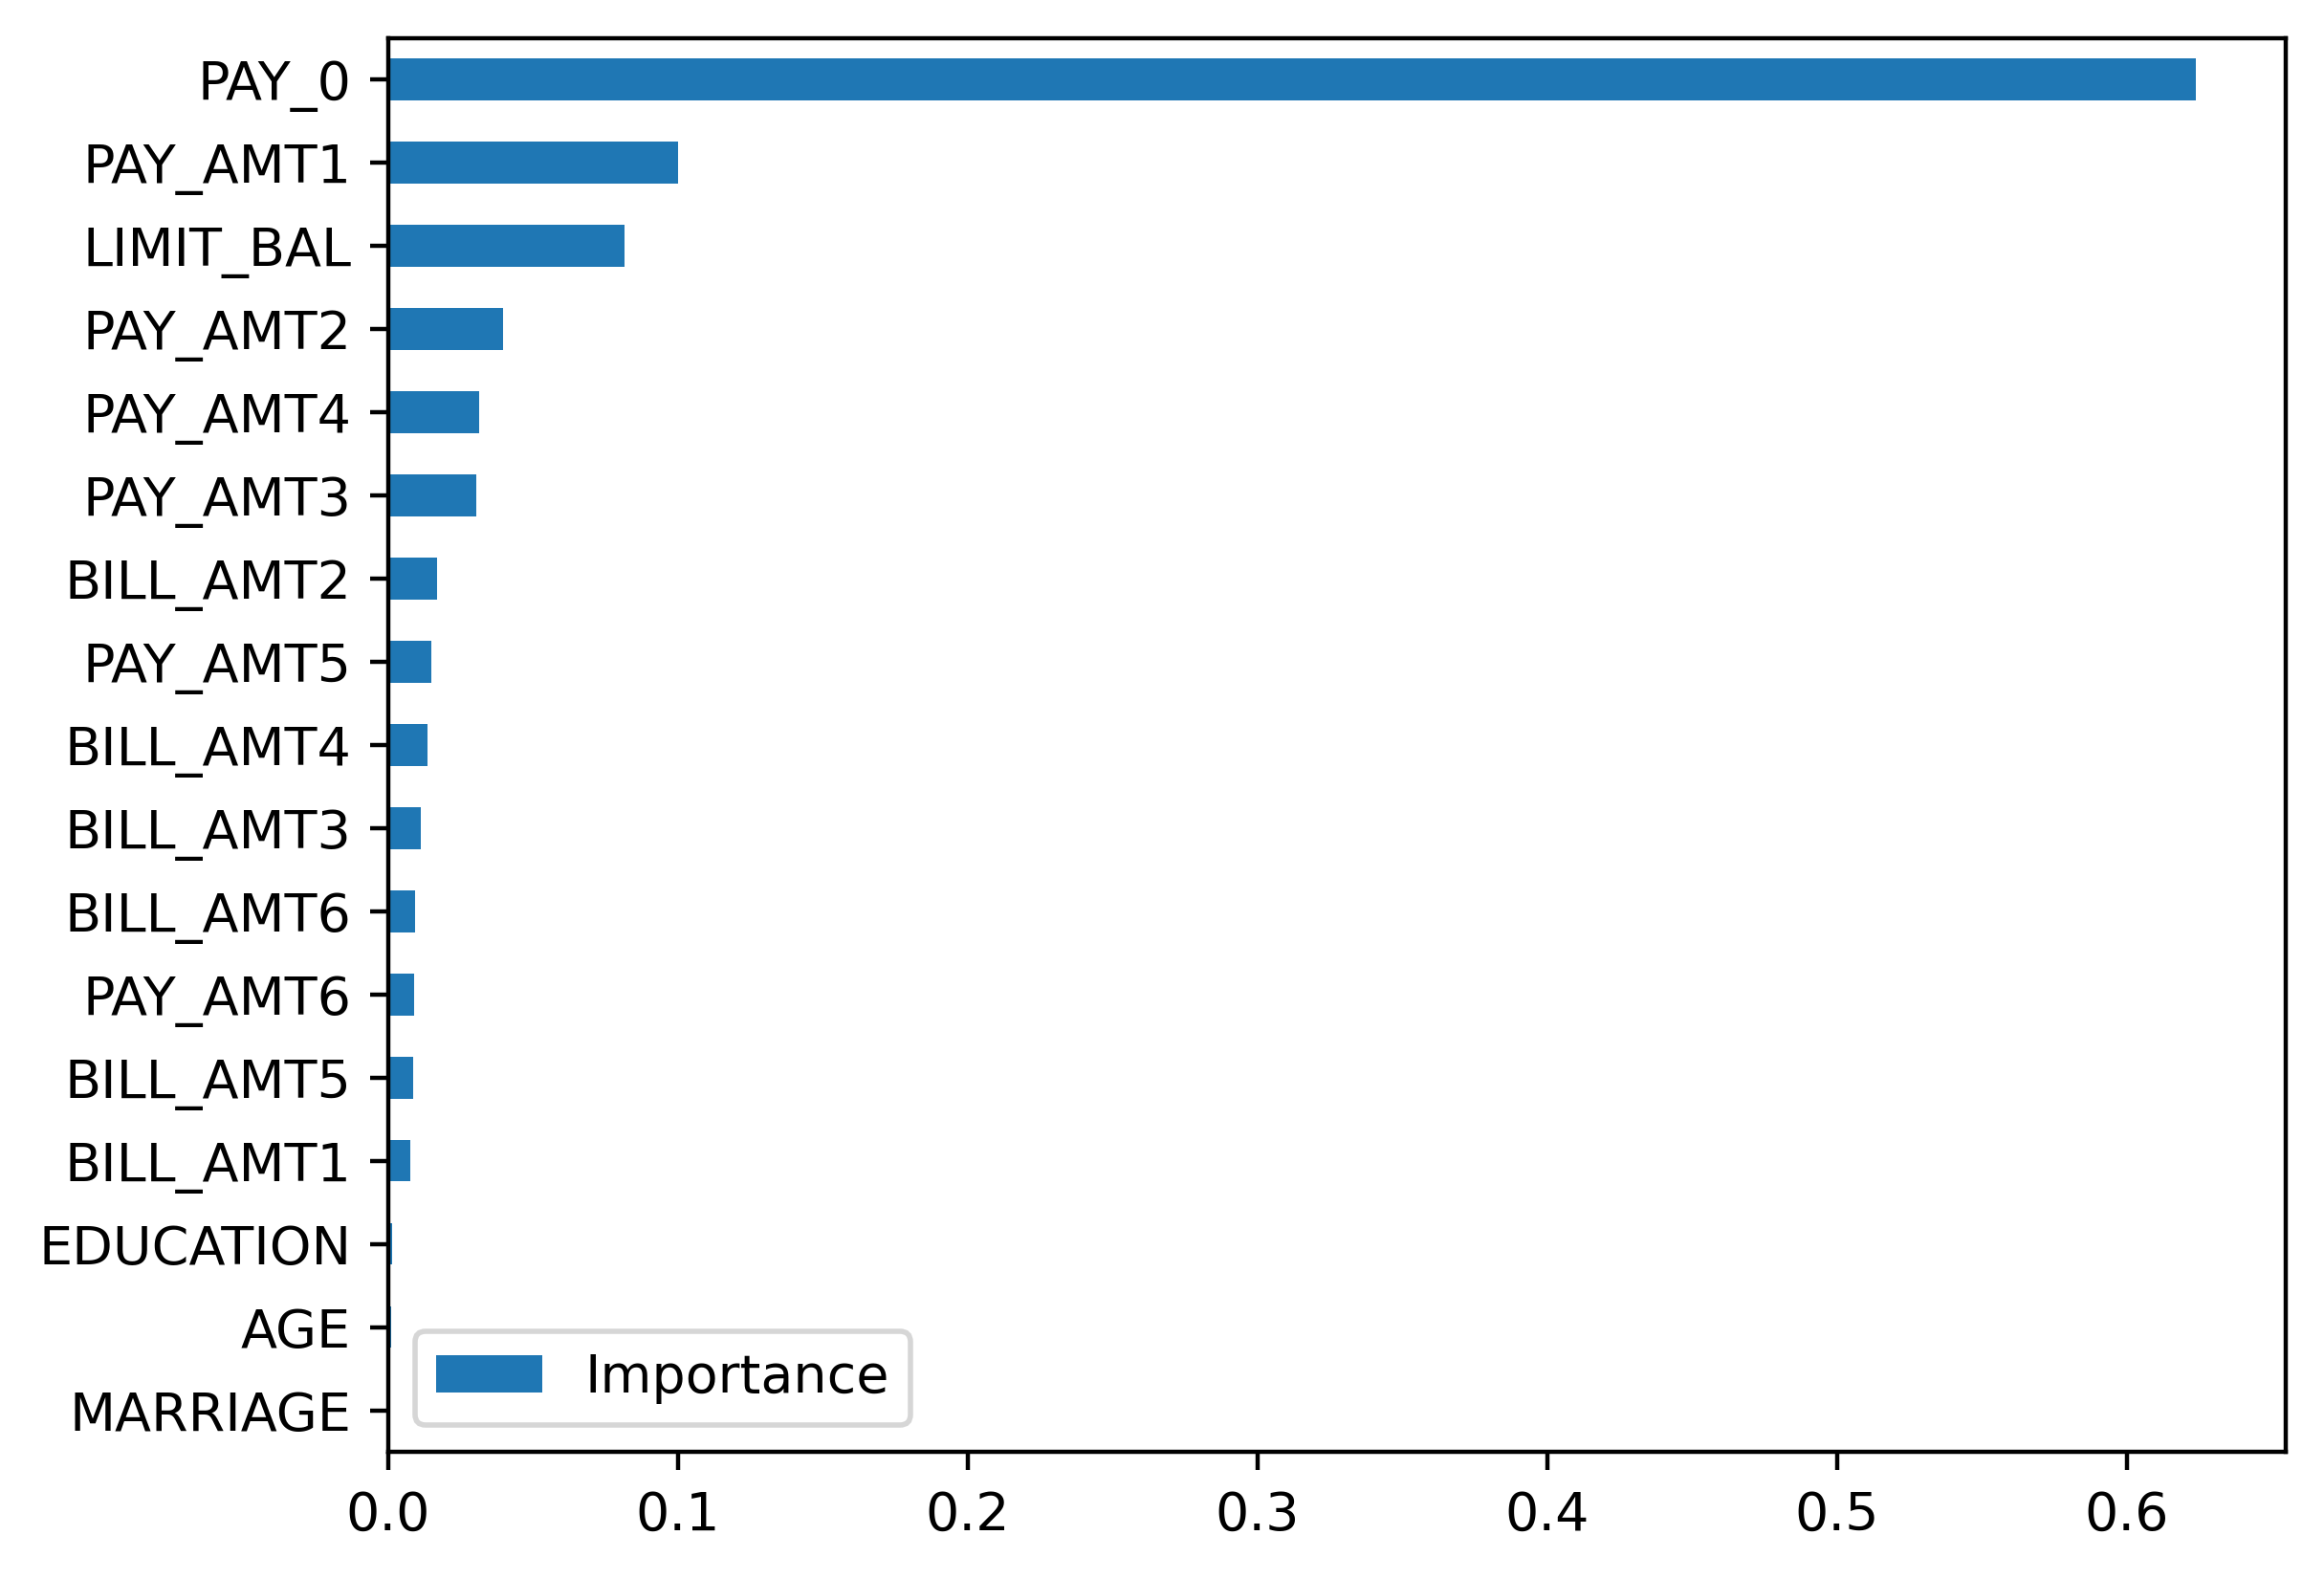

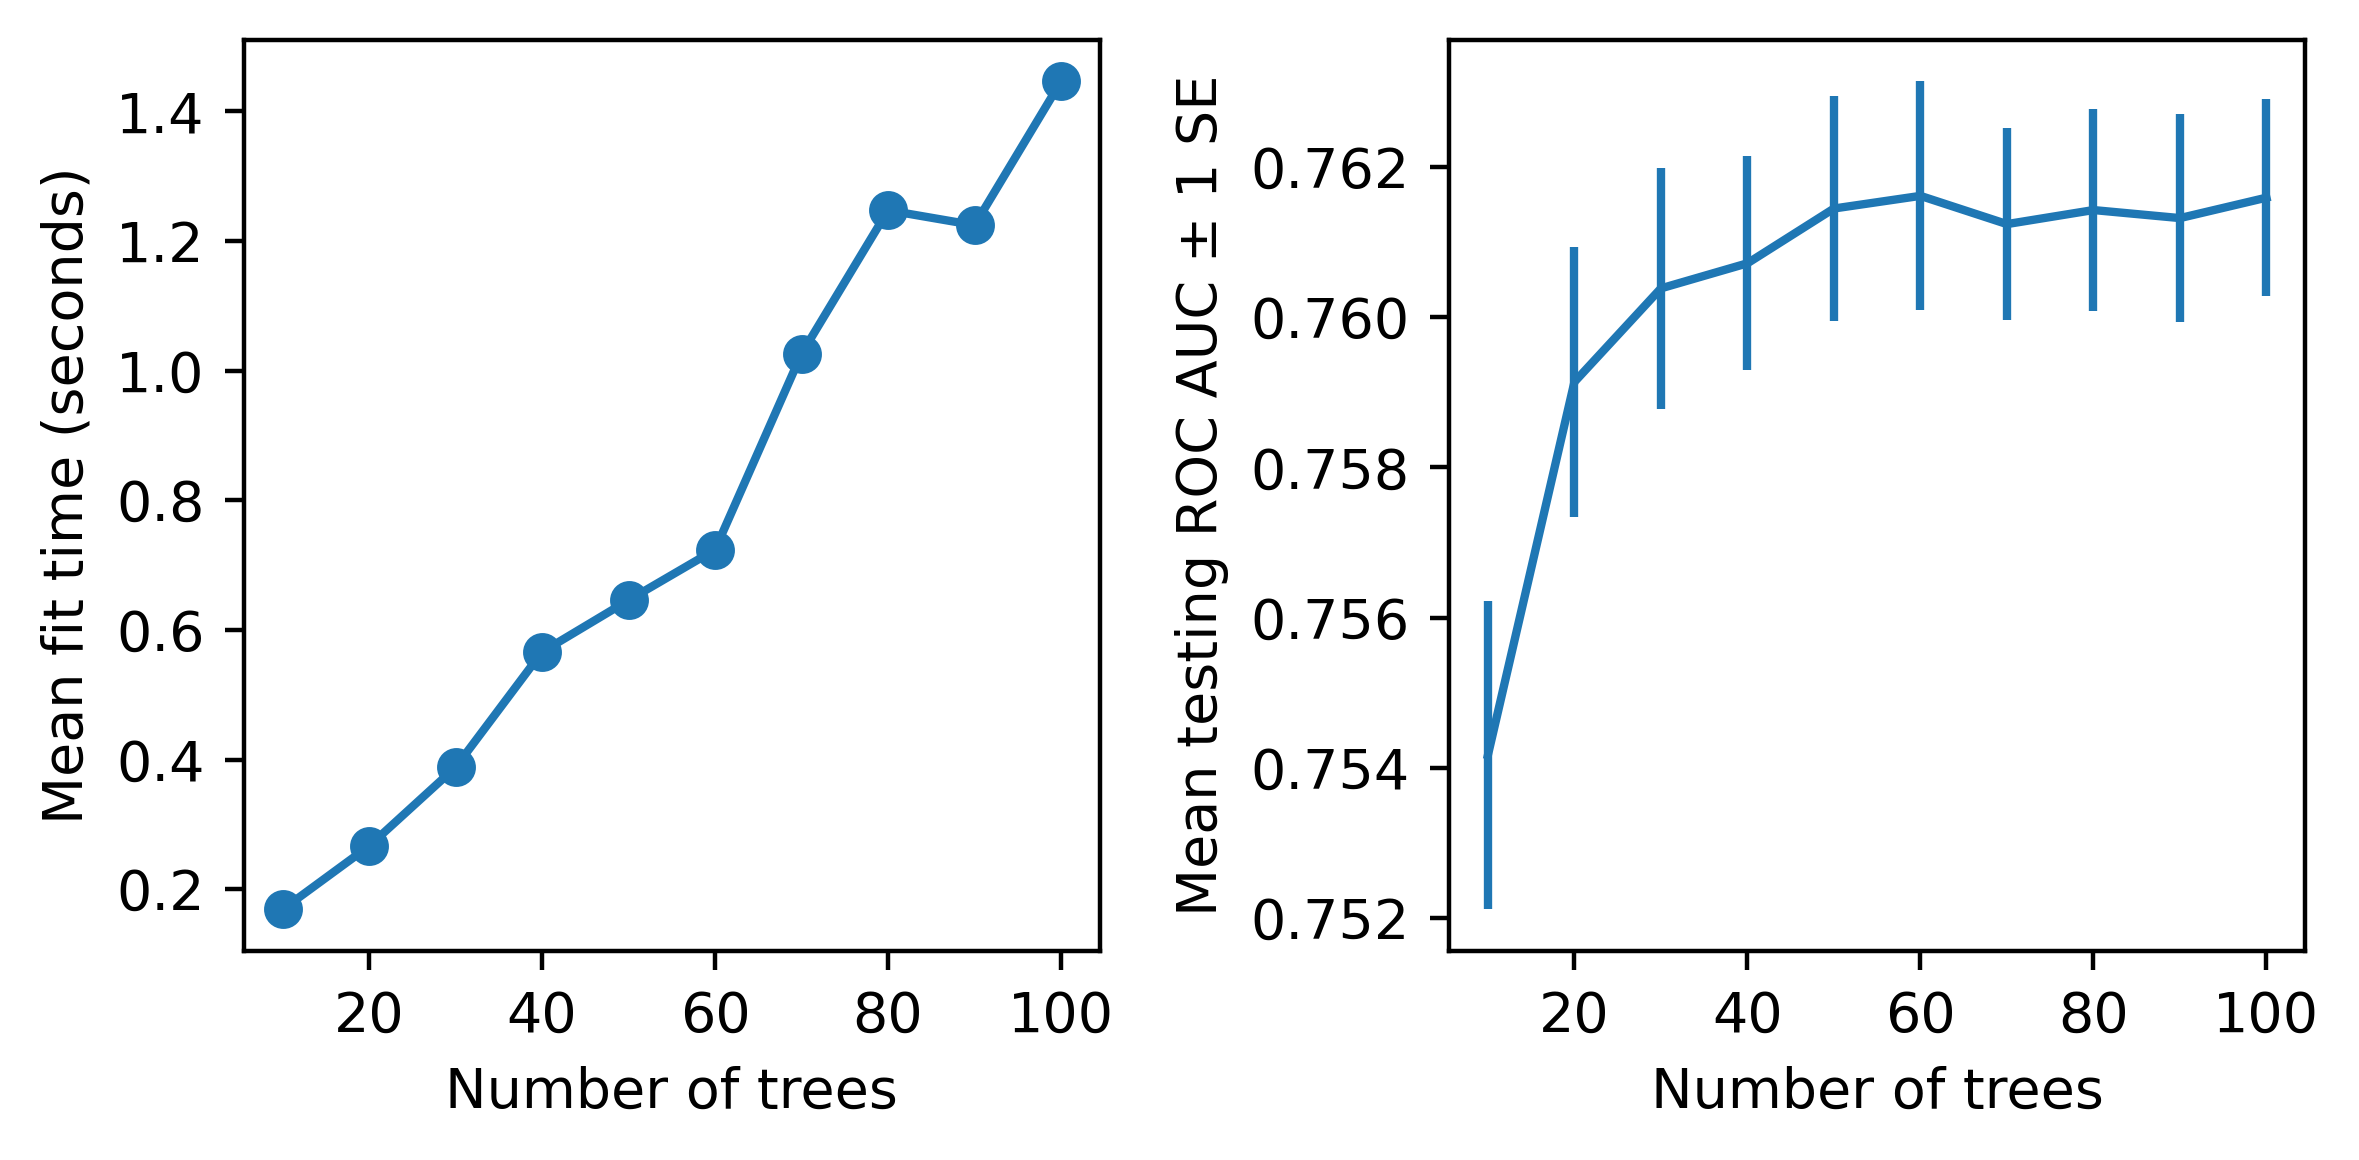

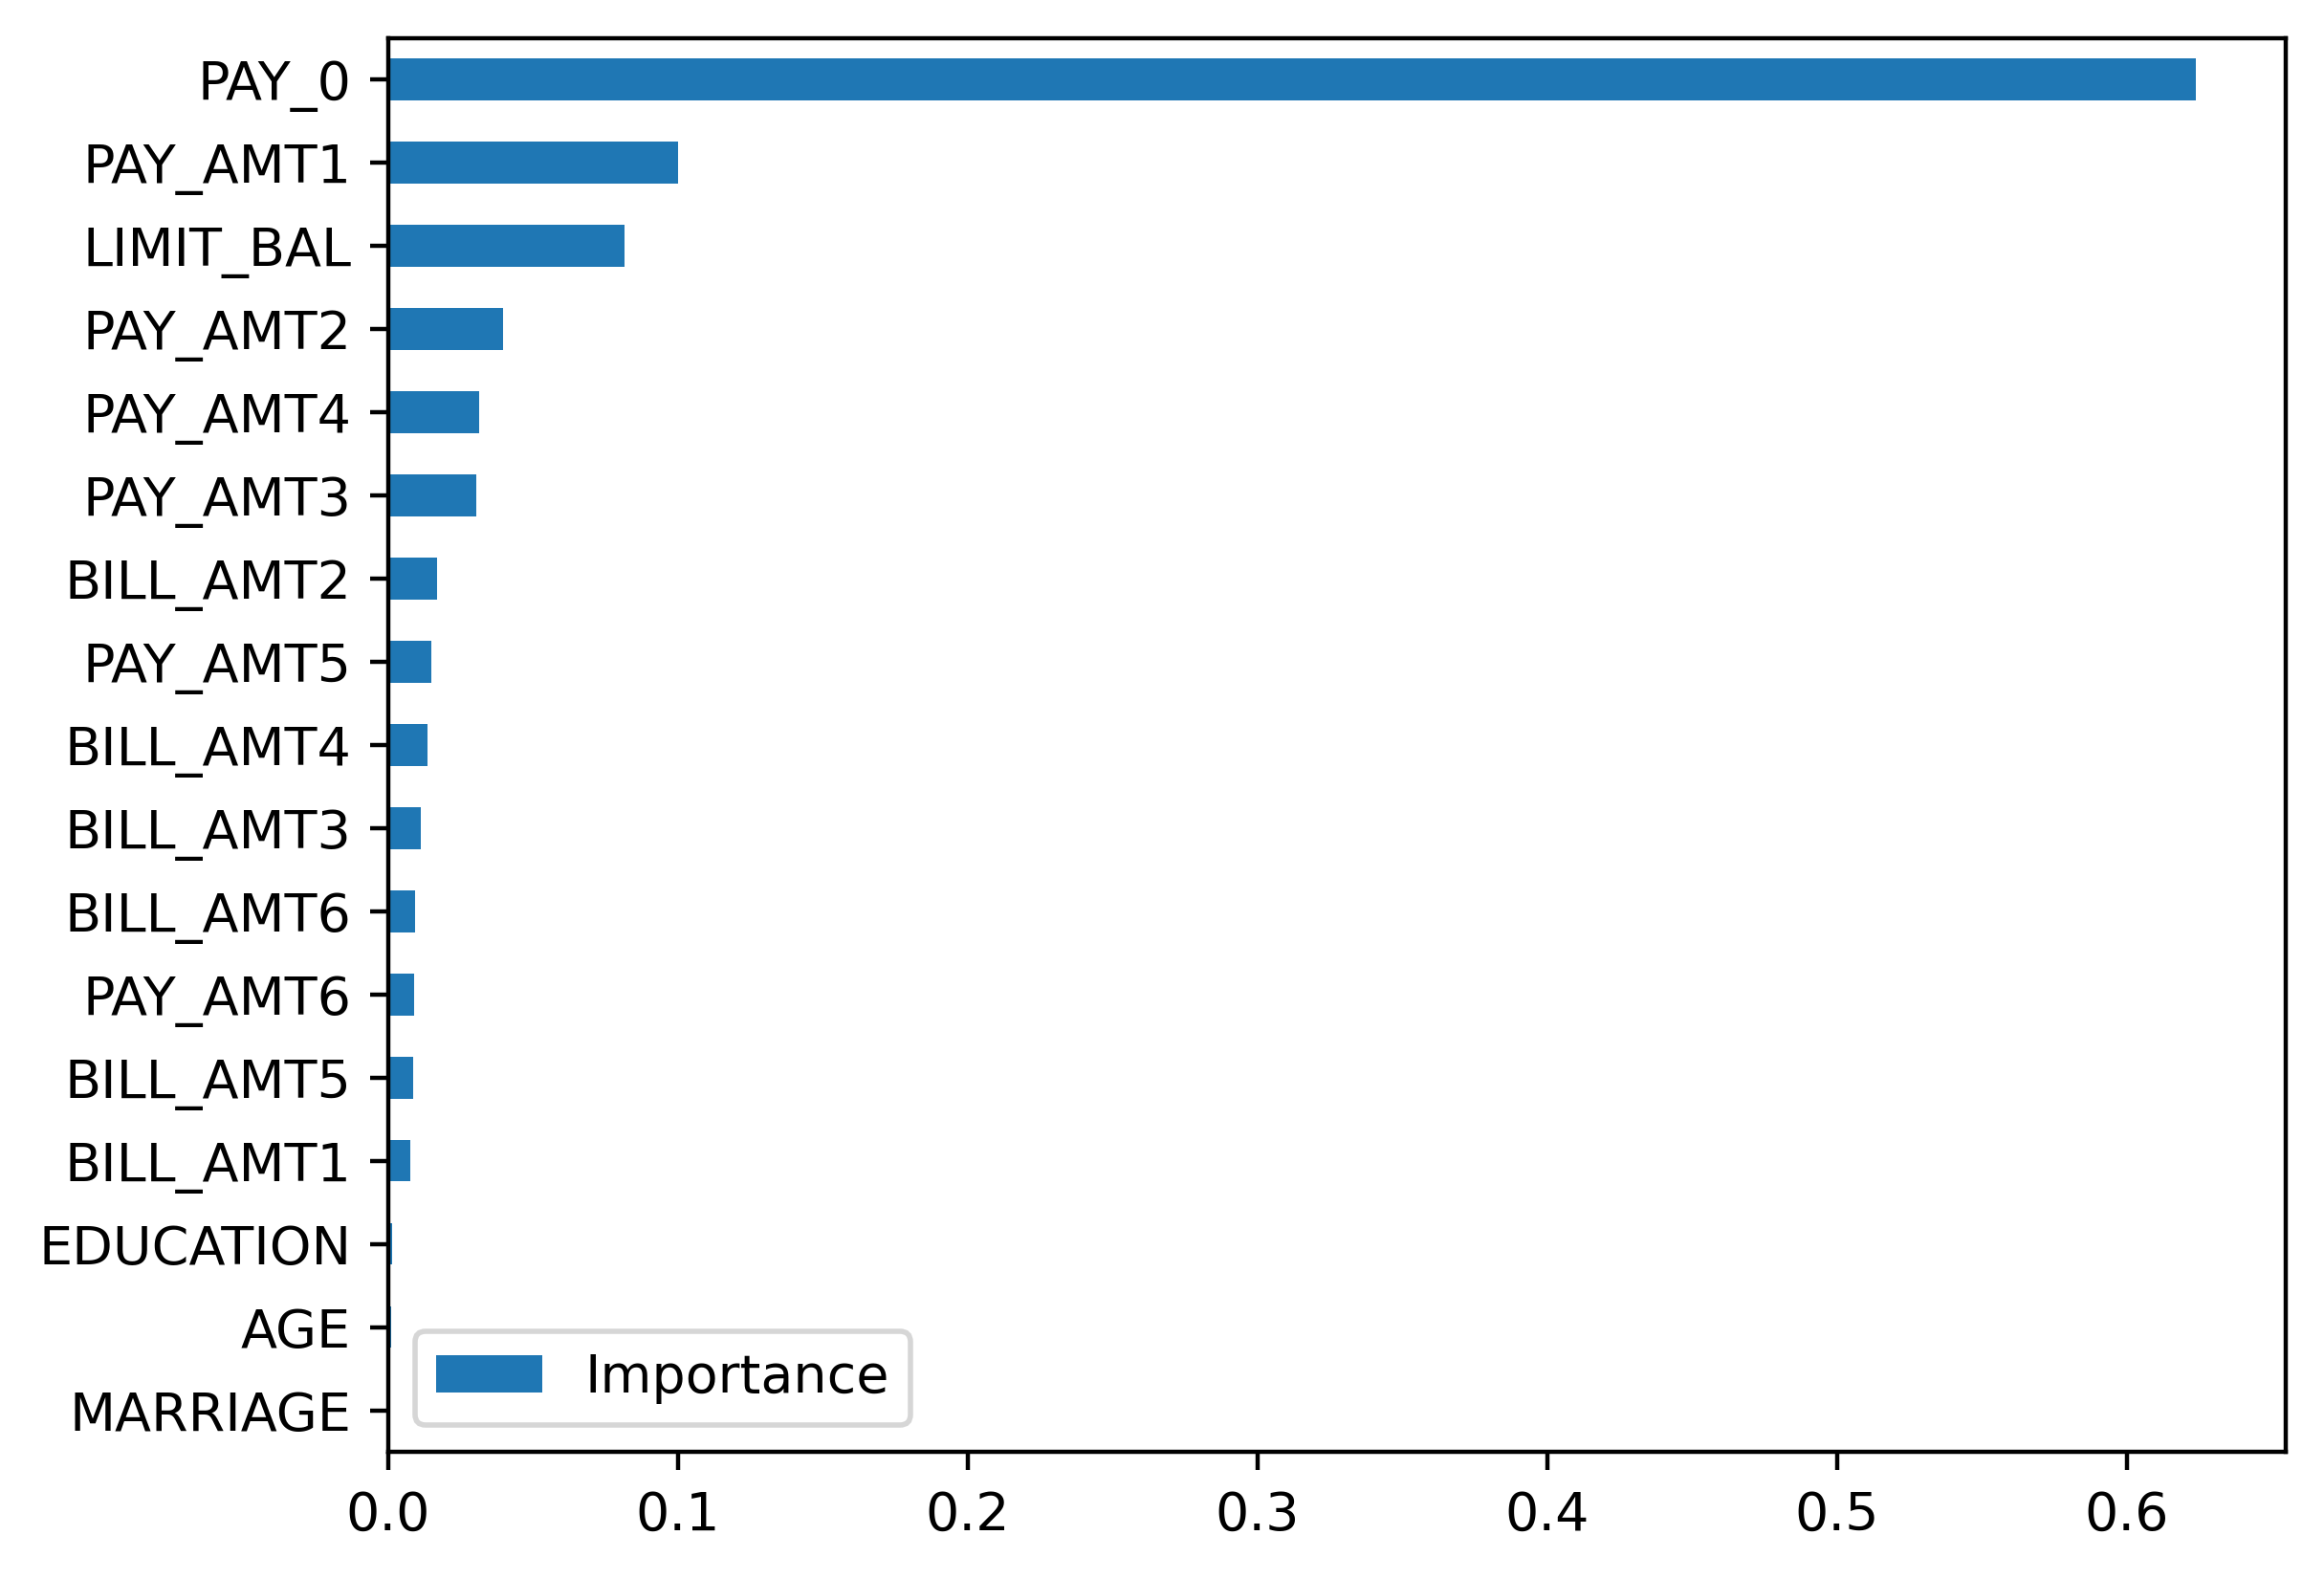

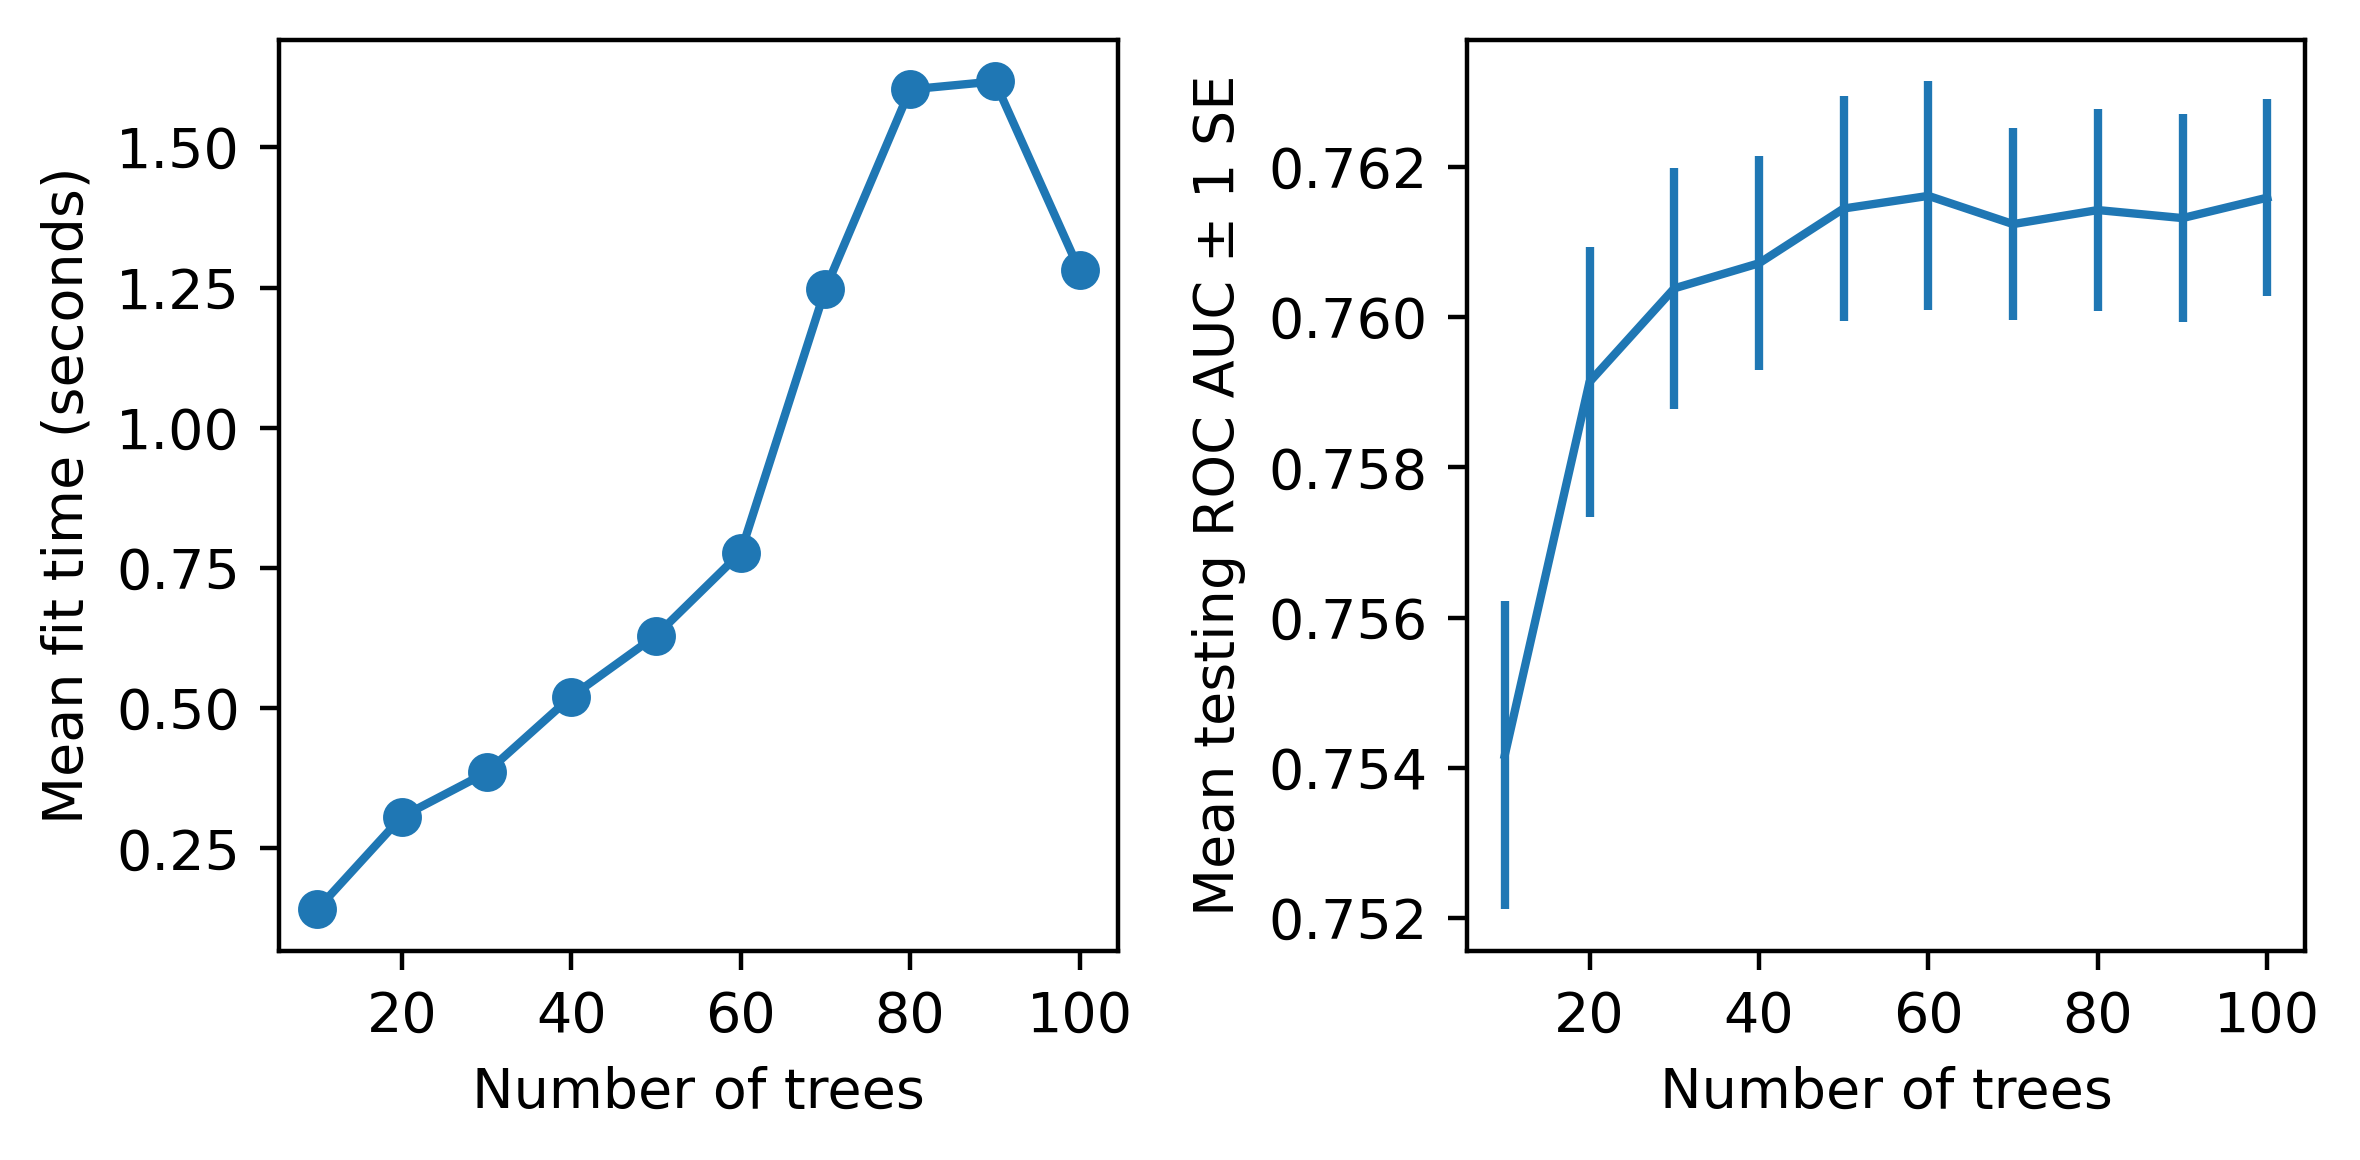

In [58]:
# Chuyển kết quả thành DataFrame
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

# Tạo biểu đồ
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'], cv_rf_ex_results_df['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'], cv_rf_ex_results_df['mean_test_score'], yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC ± 1 SE')
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()  # Đảm bảo gọi plt.show() để hiển thị hình

## Bước 6. Xem tham số tốt nhất và mức độ quan trọng của các đặc trưng

Best parameters: {'n_estimators': 60}


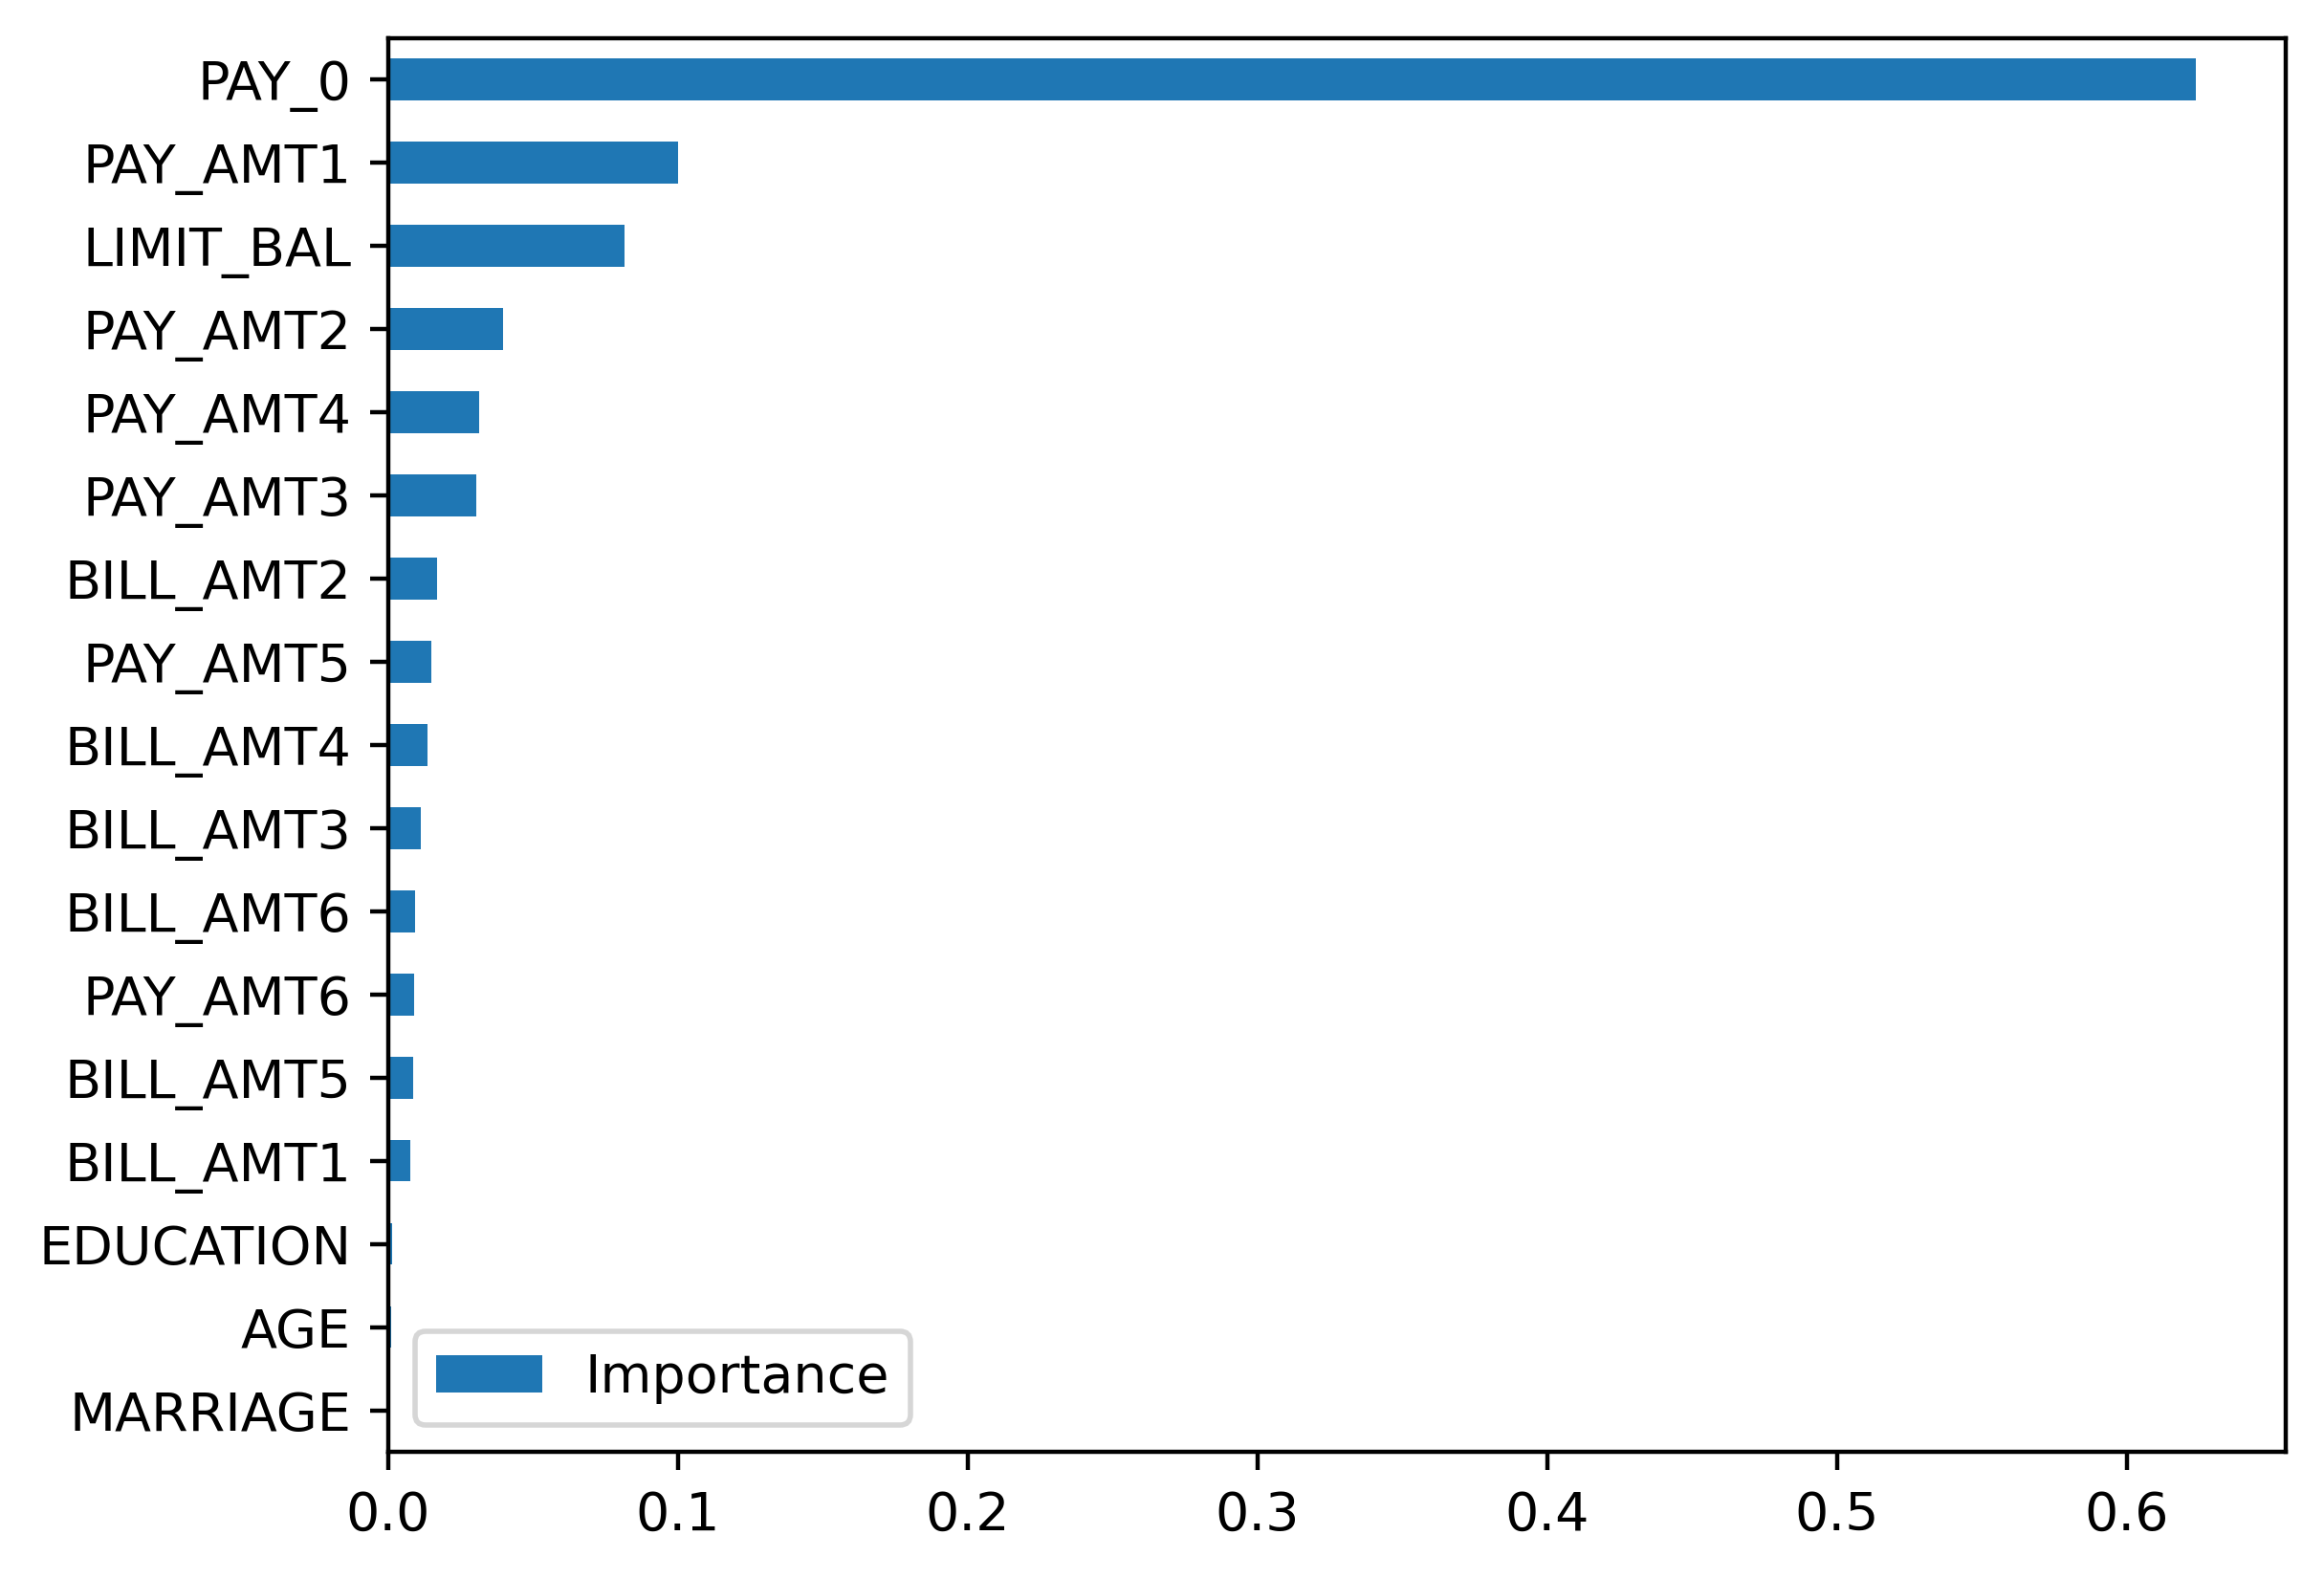

In [59]:
# In tham số tốt nhất
print("Best parameters:", cv_rf_ex.best_params_)

# Tạo DataFrame cho mức độ quan trọng của các đặc trưng
feat_imp_df = pd.DataFrame({'Importance': cv_rf_ex.best_estimator_.feature_importances_}, index=features_response[:-1])
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()

# Hiển thị biểu đồ
plt.show()  # Đảm bảo gọi plt.show() để hiển thị hình